<a href="https://colab.research.google.com/github/nata050818/Analise-Qualitativa/blob/teste_nata_colab/Grafico_analise_estatistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import pandas as pd

In [ ]:


# Carregando o DataFrame a partir de um arquivo CSV
df1 = pd.read_csv('/content/Dados testes usuários - D_acuracia_TF1_B1.csv')

# Exibindo o DataFrame
#df1

<Axes: xlabel='Acertos 2', ylabel='estrategia'>

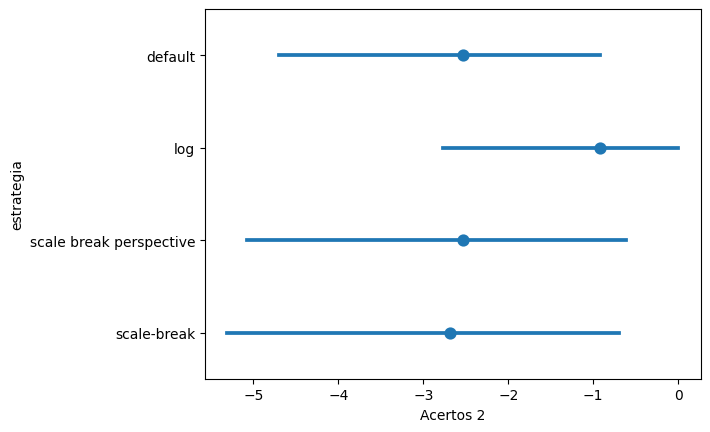

In [ ]:

sns.pointplot(
    data=df1, x="Acertos 2", y="estrategia",
    errorbar=("ci", 95), capsize=.0,
    linestyle="none", marker="o",
)


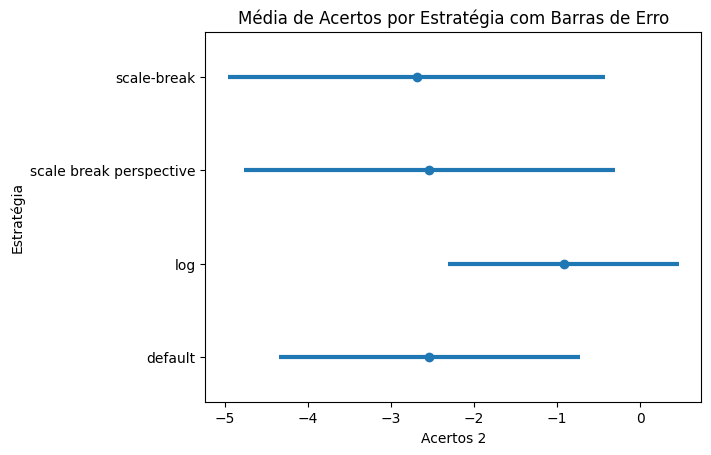

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import bootstrap

# Função para calcular média e intervalo de confiança com bootstrap
def compute_mean_and_ci(data, n_resamples=5000, ci=95):
    # Função de estatística para bootstrap
    def statistic(x):
        return np.mean(x)

    # Realiza o bootstrap
    resamples = bootstrap((data,), statistic, n_resamples=n_resamples, method='basic')
    lower_bound, upper_bound = resamples.confidence_interval
    return np.mean(data), (upper_bound - lower_bound) / 2  # Média e intervalo de erro

# Agrupar os dados por categoria e calcular médias e intervalos de confiança
grouped = df1.groupby('estrategia')['Acertos 2']
means = []
errors = []
categories = []

for name, group in grouped:
    mean, error = compute_mean_and_ci(group.values)
    means.append(mean)
    errors.append(error)
    categories.append(name)

# Criar gráfico com Matplotlib (invertido)
plt.errorbar(means, categories, xerr=errors, fmt='o', label='Média com IC', elinewidth=3)

plt.margins(0.05, 0.16)
# Adicionar rótulos e título
plt.xlabel('Acertos 2')
plt.ylabel('Estratégia')
plt.title('Média de Acertos por Estratégia com Barras de Erro')

# Exibir gráfico
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import bootstrap
import seaborn as sns

# Função para calcular média e intervalo de confiança com bootstrap
def compute_mean_and_ci(data, n_resamples=5000, ci=95):
    def statistic(x):
        return np.mean(x)

    resamples = bootstrap((data,), statistic, n_resamples=n_resamples, method='basic')
    lower_bound, upper_bound = resamples.confidence_interval
    return np.mean(data), (upper_bound - lower_bound) / 2  # Média e intervalo de erro

# Calcular médias e intervalos de confiança por combinação de 'estrategia' e 'base'
results = []
for (estrategia, base), group in df.groupby(['estrategia', 'base']):
    mean, error = compute_mean_and_ci(group['Acertos 2'].values)
    results.append({
        'estrategia': estrategia,
        'base': base,
        'mean': mean,
        'error': error
    })

results_df = pd.DataFrame(results)

# Criar gráfico facetado
g = sns.FacetGrid(results_df, col="base",col_wrap=2, margin_titles=True, sharex=True, sharey=True)

# Função para plotar cada gráfico
def plot_error_bars(data, **kwargs):
    plt.errorbar(data['mean'], data['estrategia'], xerr=data['error'], fmt='o', elinewidth=3)
    plt.xlabel('Acertos 2')
    plt.ylabel('Estratégia')

# Mapear a função de plotagem para cada faceta
g.map_dataframe(plot_error_bars)

# Ajustar o layout
g.set_axis_labels("Acertos 2", "Estratégia")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.add_legend()

# Exibir gráfico
plt.show()


# Tarfa 1

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# df = pd.read_csv('/content/Dados testes usuários - TF1.csv')

In [ ]:
# Criar a função para ajustar os títulos com base no valor de col_name
def ajustar_titulo(col_name):
    if col_name == 1:
        return f'Base {col_name}(Exponential)'
    elif col_name == 2:
        return f'Base {col_name}(Linear)'
    elif col_name == 3:
        return f'Base {col_name}(Two outliers)'
    elif col_name == 4:
        return f'Base {col_name}(Groups of outliers )'
    else:
        return f'Base {col_name}'



/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


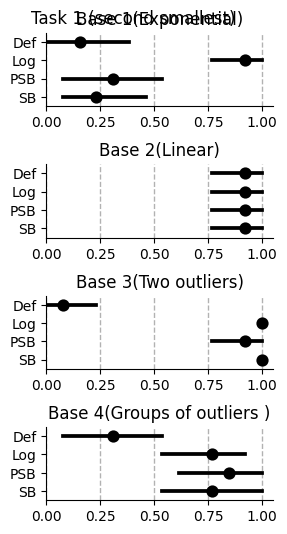

In [ ]:

# Calcula os limites do eixo x com base no DataFrame
x_min = 0
x_max = 1.05  # Ajuste conforme necessário

# Criação do FacetGrid
g = sns.FacetGrid(df, col="base", col_wrap=1,height=1.40, aspect=2.26,
                  margin_titles=False, sharex=False, sharey=False)

# Mapear o gráfico ponto para cada facet
g.map(sns.pointplot, "Acerto", "estrategia SIGLA",
      errorbar=("ci", 95), capsize=.0,
      linestyle="none", marker="o", color="black")

# Padroniza a escala do eixo x para todas as facetas
g.set(xlim=(x_min, x_max))

# Ajustar os títulos das facetas e adicionar linhas pontilhadas
for ax, col_name in zip(g.axes.flat, g.col_names):
    ax.set_title(ajustar_titulo(int(col_name)))

    for tick in ax.get_xticks():
        ax.axvline(x=tick, color='black', linestyle='--', alpha=0.3, linewidth=1)

# Ajustar os títulos dos eixos e mostrar o gráfico
g.set_axis_labels("", "")
# plt.subplots_adjust(top=0.87, hspace=0.4)
g.fig.suptitle('Task 1 (second smallest)')

# Exportar o gráfico em formato SVG
g.savefig("TF1_acuracia.svg", format='svg')

plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


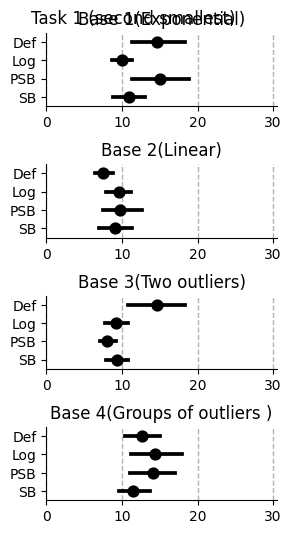

In [ ]:

# Calcula os limites do eixo x com base no DataFrame
x_min = 0
x_max = 30.5  # Ajuste conforme necessário

# Criação do FacetGrid
g = sns.FacetGrid(df, col="base", col_wrap=1,height=1.40, aspect=2.26,
                  margin_titles=False, sharex=False, sharey=False)

# Mapear o gráfico ponto para cada facet
g.map(sns.pointplot, "Diferança Tempo", "estrategia SIGLA",
      errorbar=("ci", 95), capsize=.0,
      linestyle="none", marker="o", color="black"  # Definindo a cor para preto
)

# Padroniza a escala do eixo x para todas as facetas
g.set(xlim=(x_min, x_max))

# Ajustar os títulos das facetas e adicionar linhas pontilhadas
for ax, col_name in zip(g.axes.flat, g.col_names):
    ax.set_title(ajustar_titulo(int(col_name)))

    for tick in ax.get_xticks():
        ax.axvline(x=tick, color='black', linestyle='--', alpha=0.3, linewidth=1)

# Ajustar os títulos dos eixos e mostrar o gráfico
g.set_axis_labels("", "")
# plt.subplots_adjust(top=0.87, hspace=0.4)
g.fig.suptitle('Task 1 (second smallest)')
# Exportar o gráfico em formato SVG
g.savefig("TF1_tempo.svg", format='svg')

plt.show()

# Tarefa 2

In [ ]:
df2 = pd.read_csv('/content/Dados testes usuários - TF2.csv')

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


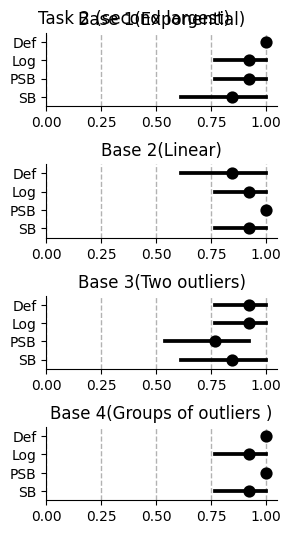

In [ ]:
# Calcula os limites do eixo x com base no DataFrame
x_min = 0
x_max = 1.05  # Ajuste conforme necessário

# Criação do FacetGrid
g = sns.FacetGrid(df2, col="base", col_wrap=1, height=1.40, aspect=2.26,
                  margin_titles=False, sharex=False, sharey=False)

# Mapear o gráfico ponto para cada facet
g.map(sns.pointplot, "Acerto", "estrategia SIGLA",
      errorbar=("ci", 95), capsize=.0,
      linestyle="none", marker="o", color="black")

# Padroniza a escala do eixo x para todas as facetas
g.set(xlim=(x_min, x_max))

# Ajustar os títulos das facetas e adicionar linhas pontilhadas
for ax, col_name in zip(g.axes.flat, g.col_names):
    ax.set_title(ajustar_titulo(int(col_name)))

    for tick in ax.get_xticks():
        ax.axvline(x=tick, color='black', linestyle='--', alpha=0.3, linewidth=1)

# Ajustar os títulos dos eixos e mostrar o gráfico
g.set_axis_labels("", "")
g.fig.suptitle('Task 2 (second largest)')

# Exportar o gráfico em formato SVG
g.savefig("TF2_acuracia.svg", format='svg')

plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


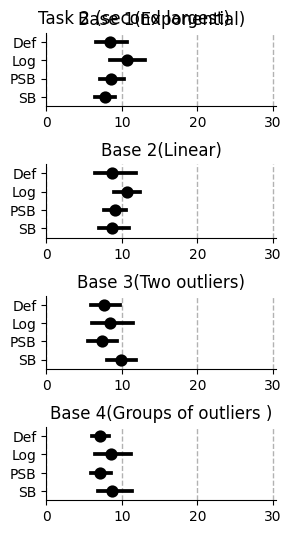

In [ ]:

# Calcula os limites do eixo x com base no DataFrame
x_min = 0
x_max = 30.5  # Ajuste conforme necessário

# Criação do FacetGrid
g = sns.FacetGrid(df2, col="base", col_wrap=1,height=1.40, aspect=2.26,
                  margin_titles=False, sharex=False, sharey=False)

# Mapear o gráfico ponto para cada facet
g.map(sns.pointplot, "Diferança Tempo", "estrategia SIGLA",
      errorbar=("ci", 95), capsize=.0,
      linestyle="none", marker="o", color="black"  # Definindo a cor para preto
)

# Padroniza a escala do eixo x para todas as facetas
g.set(xlim=(x_min, x_max))

# Ajustar os títulos das facetas e adicionar linhas pontilhadas
for ax, col_name in zip(g.axes.flat, g.col_names):
    ax.set_title(ajustar_titulo(int(col_name)))

    for tick in ax.get_xticks():
        ax.axvline(x=tick, color='black', linestyle='--', alpha=0.3, linewidth=1)

# Ajustar os títulos dos eixos e mostrar o gráfico
g.set_axis_labels("", "")
# plt.subplots_adjust(top=0.87, hspace=0.4)
g.fig.suptitle('Task 2 (second largest)')

# Exportar o gráfico em formato SVG
g.savefig("TF2_tempo.svg", format='svg')

plt.show()

# Tarefa 3

In [ ]:
df3 = pd.read_csv('/content/Dados testes usuários - TF3.csv')

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


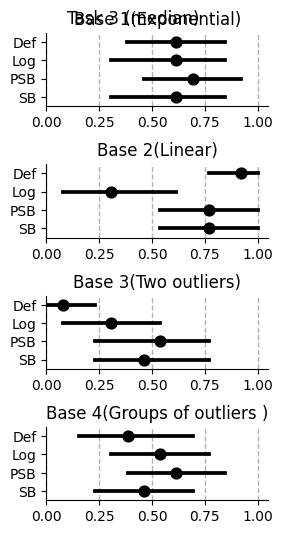

In [ ]:
# Calcula os limites do eixo x com base no DataFrame
x_min = 0
x_max = 1.05  # Ajuste conforme necessário

# Criação do FacetGrid
g = sns.FacetGrid(df3, col="base", col_wrap=1, height=1.40, aspect=2.26,
                  margin_titles=False, sharex=False, sharey=False)

# Mapear o gráfico ponto para cada facet
g.map(sns.pointplot, "Acerto", "estrategia SIGLA",
      errorbar=("ci", 95), capsize=.0,
      linestyle="none", marker="o", color="black")

# Padroniza a escala do eixo x para todas as facetas
g.set(xlim=(x_min, x_max))

# Ajustar os títulos das facetas e adicionar linhas pontilhadas
for ax, col_name in zip(g.axes.flat, g.col_names):
    ax.set_title(ajustar_titulo(int(col_name)))

    for tick in ax.get_xticks():
        ax.axvline(x=tick, color='black', linestyle='--', alpha=0.3, linewidth=1)

# Ajustar os títulos dos eixos e mostrar o gráfico
g.set_axis_labels("", "")
g.fig.suptitle('Task 3 (median)')

# Exportar o gráfico em formato SVG
g.savefig("TF3_acuracia.svg", format='svg')

plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


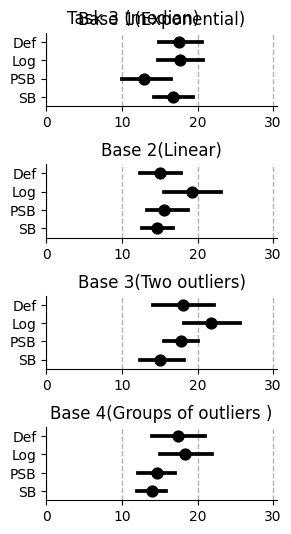

In [ ]:


# Calcula os limites do eixo x com base no DataFrame
x_min = 0
x_max = 30.5  # Ajuste conforme necessário

# Criação do FacetGrid
g = sns.FacetGrid(df3, col="base", col_wrap=1,height=1.40, aspect=2.26,
                  margin_titles=False, sharex=False, sharey=False)

# Mapear o gráfico ponto para cada facet
g.map(sns.pointplot, "Diferança Tempo", "estrategia SIGLA",
      errorbar=("ci", 95), capsize=.0,
      linestyle="none", marker="o", color="black"  # Definindo a cor para preto
)

# Padroniza a escala do eixo x para todas as facetas
g.set(xlim=(x_min, x_max))

# Ajustar os títulos das facetas e adicionar linhas pontilhadas
for ax, col_name in zip(g.axes.flat, g.col_names):
    ax.set_title(ajustar_titulo(int(col_name)))

    for tick in ax.get_xticks():
        ax.axvline(x=tick, color='black', linestyle='--', alpha=0.3, linewidth=1)

# Ajustar os títulos dos eixos e mostrar o gráfico
g.set_axis_labels("", "")
g.fig.suptitle('Task 3 (median)')

# Exportar o gráfico em formato SVG
g.savefig("TF3_tempo.svg", format='svg')

plt.show()


# Tarefa 4

In [ ]:
df4 = pd.read_csv('/content/Dados testes usuários - TF4.csv')


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


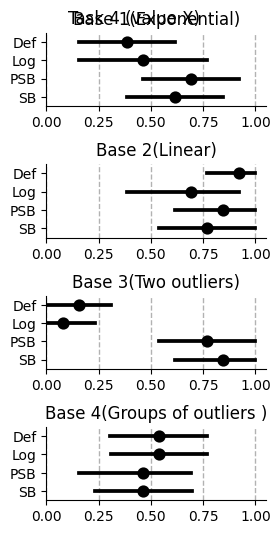

In [ ]:

# Calcula os limites do eixo x com base no DataFrame
x_min = 0
x_max = 1.05  # Ajuste conforme necessário

# Criação do FacetGrid
g = sns.FacetGrid(df4, col="base", col_wrap=1, height=1.40, aspect=2.26,
                  margin_titles=False, sharex=False, sharey=False)  # Define sharex=True

# Mapear o gráfico ponto para cada facet
g.map(sns.pointplot, "Acerto", "estrategia SIGLA",
      errorbar=("ci", 95), capsize=.0,
      linestyle="none", marker="o", color="black"  # Definindo a cor para preto
)

# Padroniza a escala do eixo x para todas as facetas
g.set(xlim=(x_min, x_max))

# Ajustar os títulos das facetas individualmente
for ax, col_name in zip(g.axes.flat, g.col_names):
    ax.set_title(ajustar_titulo(int(col_name)))

    for tick in ax.get_xticks():
        ax.axvline(x=tick, color='black', linestyle='--', alpha=0.3, linewidth=1)

# Ajustar os títulos dos eixos e mostrar o gráfico
g.set_axis_labels("", "")
g.fig.suptitle('Task 4 (value X)')

# Exportar o gráfico em formato SVG
g.savefig("TF4_acuracia.svg", format='svg')

plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


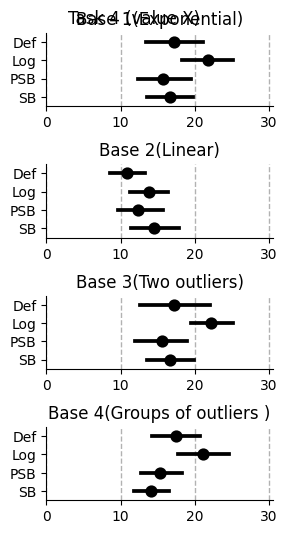

In [ ]:
# Calcula os limites do eixo x com base no DataFrame
x_min = 0
x_max = 30.5  # Ajuste conforme necessário

# Criação do FacetGrid
g = sns.FacetGrid(df4, col="base", col_wrap=1,height=1.40, aspect=2.26,
                  margin_titles=False, sharex=False, sharey=False)

# Mapear o gráfico ponto para cada facet
g.map(sns.pointplot, "Diferança Tempo", "estrategia SIGLA",
      errorbar=("ci", 95), capsize=.0,
      linestyle="none", marker="o", color="black"  # Definindo a cor para preto
)

# Padroniza a escala do eixo x para todas as facetas
g.set(xlim=(x_min, x_max))

# Ajustar os títulos das facetas e adicionar linhas pontilhadas
for ax, col_name in zip(g.axes.flat, g.col_names):
    ax.set_title(ajustar_titulo(int(col_name)))

    for tick in ax.get_xticks():
        ax.axvline(x=tick, color='black', linestyle='--', alpha=0.3, linewidth=1)

# Ajustar os títulos dos eixos e mostrar o gráfico
g.set_axis_labels("", "")
g.fig.suptitle('Task 4 (value X)')

# Exportar o gráfico em formato SVG
g.savefig("TF4_tempo.svg", format='svg')


plt.show()